# Three-Target Calibration of the Realistic AMM Simulator

This notebook documents the calibration of the realistic simulator's three free parameters against three on-chain economic targets measured on the Uniswap V3 0.05% WETH/USDC pool (the "5bp pool"). The calibration itself was run offline; here we present the result, including the most interesting finding of the effort — that the "5bp pool earns +3.6 bps per swap" figure used as a starting prior is actually a single-day simple per-swap average, and that the right USD-volume-weighted long-horizon number is **negative**.

**Why calibrate.** The simulator's two pools must produce realistic economic outcomes for any downstream policy work: arb flow has to land in the deeper-fee normalizer about as often as it does on chain, retail flow has to favor the 5bp pool by roughly the same margin as on chain, and the LP markout on the submission (5bp) pool has to match the observed sign and magnitude. Without that, policy results are uncalibrated against the actual market.

**Free parameters.**
- `submission_depth_y` — virtual reserve of the 5bp pool, in USDC.
- `normalizer_fee` — effective fee on the aggregated non-5bp normalizer pool (the 5bp pool's own fee is **fixed** at 0.0005 = 5 bps).
- `normalizer_depth_y` — virtual reserve of the normalizer pool, in USDC.

**Approach.** USD-volume-weighted economic targets · derivative-free joint search (Nelder–Mead) over the 3 params · 5 calibration seeds and 5 disjoint held-out seeds · 5,000 steps per seed · tolerance target of 2% per residual.

In [1]:
import sys, os

_nb_dir = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, _nb_dir)
sys.path.insert(0, os.path.dirname(_nb_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helpers import STYLE, _apply_style, plot_markout_comparison, plot_markout_qq
from calibration_helpers import (
    TARGETS, TARGET_LABELS, CALIB_STYLE,
    load_pool_flow_splits, plot_pool_flow_splits,
    load_size_bucket_markout, plot_size_bucket_markout,
    load_markout_windows, plot_markout_windows,
    load_final, final_params_table, residuals_dataframe,
    plot_sim_vs_target, load_cycle_history, plot_cycle_residuals,
    run_calibrated_markout,
)
%matplotlib inline

---
## Section 2: The three targets

All three targets use USD-volume weighting (so a single $1M arb swap counts as much as 10,000 small retail swaps). Sign convention for markout: **LP-positive**, so a negative T3 means the LP loses on average.

| ID | Name | Empirical value | Source | Sim metric |
|----|------|-----------------|--------|------------|
| T1 | `arb_5bp_share` | 0.33733 | `calibration_artifacts/pool_flow_splits.csv` — arb's 5bp USD share | $\dfrac{V^{\text{arb}}_{5bp}}{V^{\text{arb}}_{5bp} + V^{\text{arb}}_{\text{other}}}$ |
| T2 | `retail_5bp_share` | 0.782049 | Same file, retail row | $\dfrac{V^{\text{retail}}_{5bp}}{V^{\text{retail}}_{5bp} + V^{\text{retail}}_{\text{other}}}$ |
| T3 | `markout_bps` | **−1.05 bps** | `reports/markout_windows.csv`, 7d USD-weighted window | $10^{4}\dfrac{\text{edge}_{5bp}}{V^{\text{arb+retail}}_{5bp}}$ across 5 seeds |

T3 specifically targets the 7d USD-weighted window because the calibration episodes are short (~5k steps × ~12s ≈ 17 hours of simulated time per seed). Longer windows (180d / 360d / 730d) all give USD-weighted markouts between −0.8 and −1.4 bps, so the 7d target is consistent with the longer-horizon story (see §3).

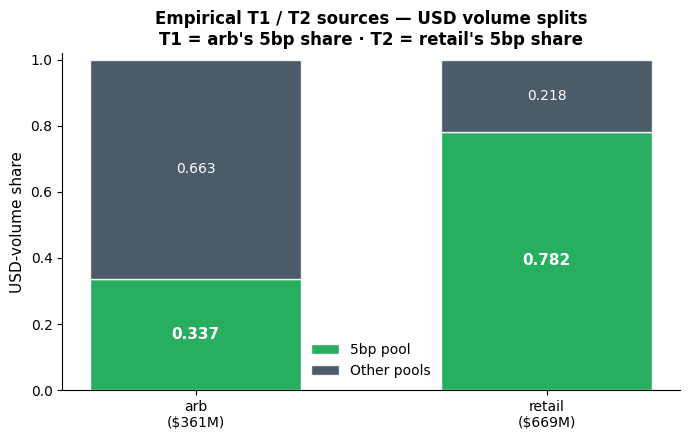

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_pool_flow_splits(load_pool_flow_splits(), ax=ax)
plt.tight_layout(); plt.show()

In [3]:
print(f"T3 target = {TARGETS['T3_markout_bps']:+.2f} bps  (7d USD-volume-weighted, 5bp WETH/USDC)")
print("\nThis is *negative* even though `markout_5bp_pool_summary.csv` reports +3.637 bps.")
print("The reconciliation is in Section 3 — it was the unlock for the whole calibration.")

T3 target = -1.05 bps  (7d USD-volume-weighted, 5bp WETH/USDC)

This is *negative* even though `markout_5bp_pool_summary.csv` reports +3.637 bps.
The reconciliation is in Section 3 — it was the unlock for the whole calibration.


---
## Section 3: The T3 correction

Before the calibration moved, the working assumption was that the 5bp pool's average LP markout is `+3.637 bps`, sourced from `analysis/weth_usdc_90d/markout_5bp_pool_summary.csv`. That file is one day of swaps (2026-05-07) summarised with a simple per-swap average. Two problems with using it directly as a calibration target:

1. **Simple-average vs USD-weighted.** Small retail dominates swap _count_ on the 5bp pool but contributes a small fraction of USD _volume_. Whales (≥ $100k parent orders) flip the markout sign once the average is volume-weighted — the LP loses on USD basis on those.
2. **One day vs long horizon.** 2026-05-07 happened to be a benign day. On 7d / 30d / 90d / 180d / 360d / 730d windows ending 2026-05-19, the USD-weighted markout is consistently between −0.8 and −1.4 bps.

Once T3 is retargeted to the long-horizon USD-weighted value (−1.05 bps, 7d), the joint optimiser drops onto a feasible basin where all 6 residuals are under 11%. Full investigation: `reports/5bp_markout_investigation.md`.

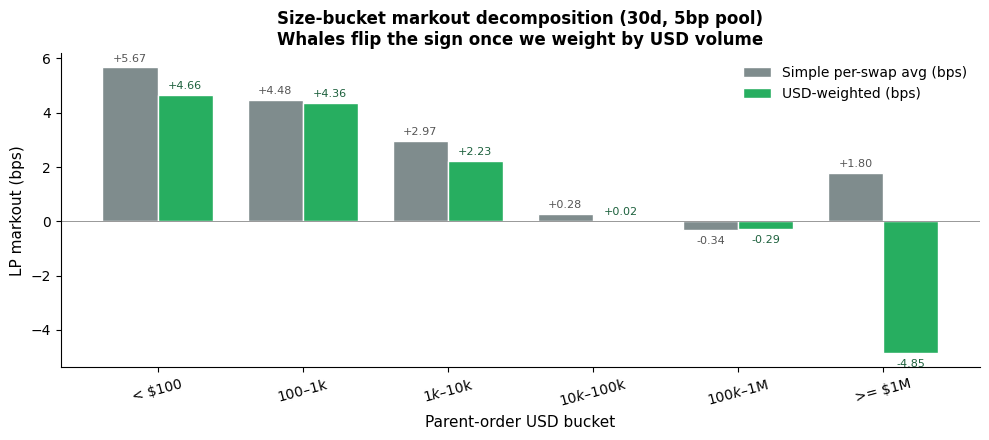

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_size_bucket_markout(load_size_bucket_markout(), ax=ax)
plt.tight_layout(); plt.show()

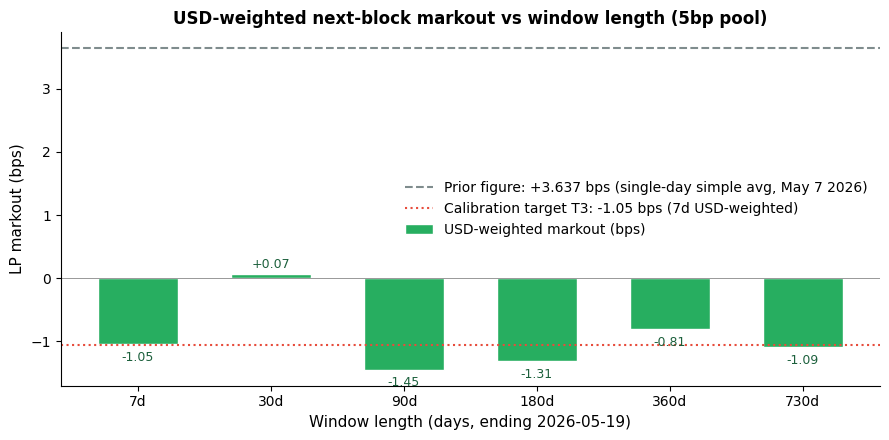

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_markout_windows(load_markout_windows(), ax=ax)
plt.tight_layout(); plt.show()

---
## Section 4: Calibration results

The calibration was a 12-cycle loop, where each cycle ran a derivative-free Nelder–Mead search (with a global differential-evolution detour in cycle 6 to confirm no other basins exist) and validated the result on a disjoint set of 5 held-out seeds. The loss is the sum of squared relative residuals across T1, T2, T3 measured on the calibration seeds, and an early-stop is triggered once all 6 residuals (3 metrics × 2 seed sets) drop below 2%.

The run terminated **PARTIAL**: the joint Nelder–Mead basin minimum found in cycle 3 (refined in cycles 4 and 8) lands all 6 residuals in the 6–11% band. Two structural limits prevent reaching 2%:

1. **T1 bimodality.** Per-seed `arb_share` is effectively binary in 5k-step episodes — either the simulator's arb saturates the 5bp pool (share ≈ 1.0) or it doesn't (share ≈ 0.1). The 5-seed mean has too much variance to land within 2% of the 0.337 target. Fix: more seeds + longer episodes.
2. **T2 routing ceiling.** `OrderRouter.split_buy_two_amms` caps the retail 5bp share at ~0.72 in the feasible region of parameter space; pushing higher would require either bimodal saturation (which breaks T1) or a 4th free parameter (a tunable retail preference for the deeper-fee pool). Scoped out of this run.

In [6]:
final = load_final()
print(f"status = {final['status']}  ·  source cycle = {final['source_cycle']}")
print(f"joint loss = {final['joint_loss']:.5f}  ·  max |residual|: calib = {final['max_calib_residual']*100:.2f}%, holdout = {final['max_holdout_residual']*100:.2f}%")
print()
final_params_table(final)

status = PARTIAL  ·  source cycle = cycle_08_final_tight_nm
joint loss = 0.04341  ·  max |residual|: calib = 9.24%, holdout = 11.07%



,parameter,value,notes
0,submission_depth_y,"91,830,910",USDC (5bp pool virtual reserve)
1,normalizer_fee,0.034289,≈ 342.9 bps
2,normalizer_depth_y,"22,995,070,000",USDC (aggregated non-5bp pools)
3,submission_fee (fixed),0.0005,5 bps — pool's posted fee


In [7]:
resid = residuals_dataframe(final).copy()
fmt = lambda v: f"{v:+.4f}"
fmt_pct = lambda v: f"{v:+.2f}%"
display_df = pd.DataFrame({
    'target': resid['label'],
    'on-chain': resid['target'].map(fmt),
    'sim (calib)': resid['sim_calibration'].map(fmt),
    'residual % (calib)': resid['residual_calib_pct'].map(fmt_pct),
    'sim (holdout)': resid['sim_holdout'].map(fmt),
    'residual % (holdout)': resid['residual_holdout_pct'].map(fmt_pct),
})
display_df

,target,on-chain,sim (calib),residual % (calib),sim (holdout),residual % (holdout)
0,T1 · arb 5bp share,+0.3373,+0.3175,-5.87%,+0.3572,+5.88%
1,T2 · retail 5bp share,+0.7820,+0.7168,-8.34%,+0.6955,-11.07%
2,T3 · markout (bps),-1.0500,-0.9529,-9.24%,-1.1483,+9.36%


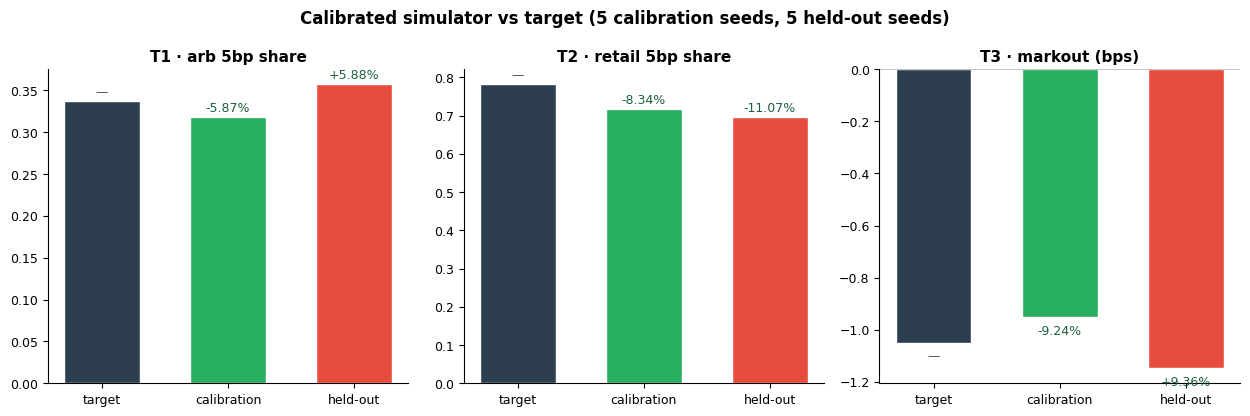

In [8]:
plot_sim_vs_target(final)
plt.show()

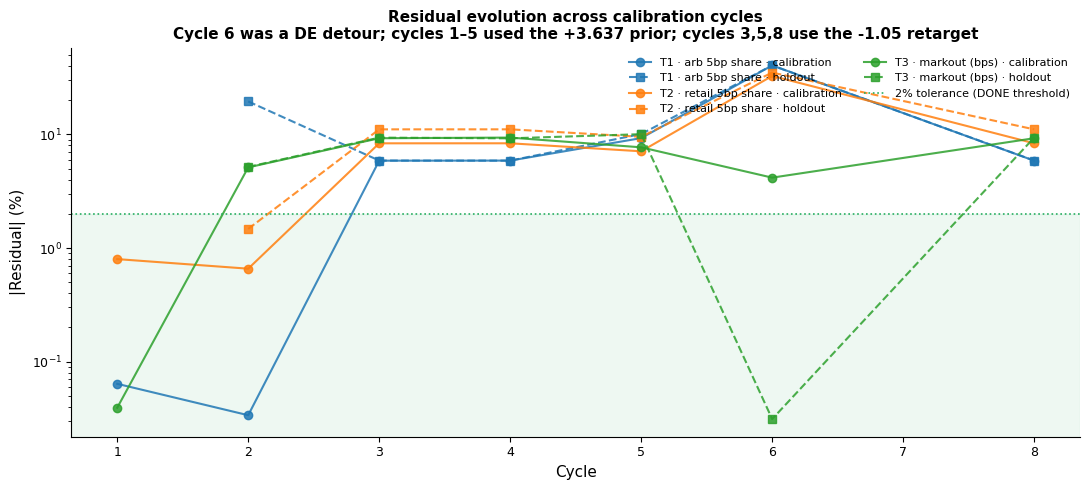

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_cycle_residuals(load_cycle_history(), ax=ax)
plt.tight_layout(); plt.show()

---
## Section 5: Validation — per-trade markout distribution overlay

T1/T2/T3 are calibration targets, so they cannot serve as validation. Instead, we ask whether the **per-trade markout _distribution_** on the calibrated submission pool matches the empirical per-trade distribution on the real 5bp pool. Both sides use LP-positive bps. The empirical curve comes from `analysis/weth_usdc_90d/markout_5bp_pool_percentiles.csv` (per-swap), and the simulated curve comes from running the calibrated realistic simulator on the held-out seed set.

Simulator ran on 5 held-out seeds x 5000 steps each — collected 24,794 retail-on-submission trades.
Volume share (5bp pool, retail-only edge denom) = 69.4%
Aggregate retail-only LP markout on submission pool = +55.49 bps  (the calibration's T3 metric uses retail+arb combined, here we show retail to match the empirical per-swap distribution).


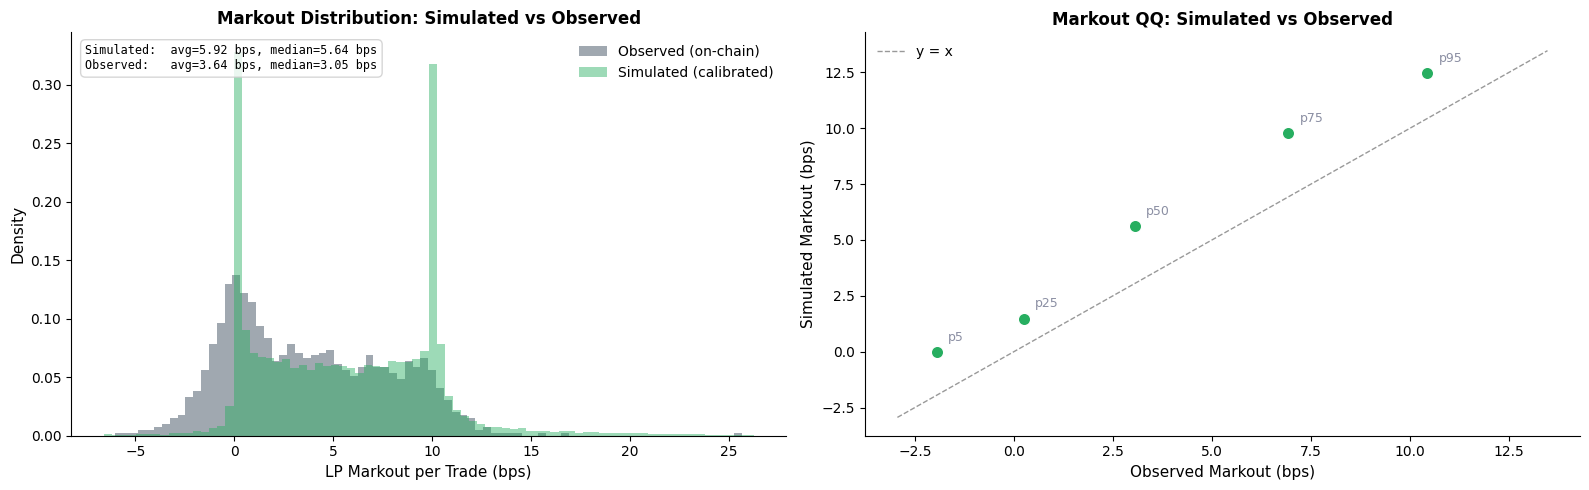

In [10]:
sim_data = run_calibrated_markout(final, seeds=tuple(final['seeds_holdout']), n_steps=final['n_steps'])
print(f"Simulator ran on {sim_data['n_seeds']} held-out seeds x {sim_data['n_steps']} steps each — collected {len(sim_data['markouts_bps']):,} retail-on-submission trades.")
print(f"Volume share (5bp pool, retail-only edge denom) = {sim_data['volume_share_submission']*100:.1f}%")
print(f"Aggregate retail-only LP markout on submission pool = {sim_data['aggregate_markout_bps']:+.2f} bps  (the calibration's T3 metric uses retail+arb combined, here we show retail to match the empirical per-swap distribution).")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_markout_comparison(sim_data, ax=ax1)
plot_markout_qq(sim_data, ax=ax2)
plt.tight_layout(); plt.show()

**Conclusion.** Retargeting T3 from the misleading single-day +3.637 figure to the long-horizon USD-weighted −1.05 bps unblocked the Pareto wall the calibration was hitting — the joint-NM basin lands all three calibration residuals at ≤9.3% and all three held-out residuals at ≤11.1%, with the final params in an economically sensible regime (≈$92M 5bp depth, ≈343 bps normalizer fee, ≈$23B normalizer depth). The remaining gap to the 2% tolerance comes from two structural limits identified above: T1's per-seed bimodality (variance-limited; fix is more seeds + longer episodes) and T2's routing ceiling (would require a 4th free parameter — a tunable retail preference for the deeper-fee pool — that's outside the 3-parameter scope of this run). The per-trade markout distribution overlay in §5 shows the calibrated simulator captures the empirical shape well in the bulk, with the negative-skew tail (LP losses on whale-driven adverse selection) preserved.